In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv("smartcart_customers.csv")

In [4]:
df.head()  # total shape(2240,22)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [5]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

# Data Preprocessing

## 1. Handle Missing Values

In [6]:
df["Income"]=df["Income"].fillna(df["Income"].median())

In [7]:
df.isnull().sum()
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


## Feature Engineering

In [8]:
#Changing year of birth into which gives even more meaningfull information
from datetime import date

df["Age"]=2026-df["Year_Birth"]

In [9]:
df["Age"].head()

0    69
1    72
2    61
3    42
4    45
Name: Age, dtype: int64

In [10]:
# Handling date of customer joining , changing join date to tenure date by taking the latest date as a reference

df["Dt_Customer"]=pd.to_datetime(df["Dt_Customer"], dayfirst=True) #convert to python date time

In [11]:
df["Dt_Customer"].head()

reference_date=df["Dt_Customer"].max()

df["Customer_Tenure_Days"]=(reference_date-df["Dt_Customer"]).dt.days

In [12]:
df["Customer_Tenure_Days"]
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,88,3,8,10,4,7,0,1,69,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,6,2,1,1,2,5,0,0,72,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,42,1,8,2,10,4,0,0,61,312
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,5,2,2,0,4,6,0,0,42,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,15,5,5,3,6,5,0,0,45,161


In [13]:
# Combining Spending

df["Total_Spending"]=df["MntWines"]+df["MntFruits"]+df["MntMeatProducts"]+df["MntFishProducts"]+df["MntSweetProducts"]+df["MntGoldProds"]

#Combining Children
df["Total_Children"]=df["Kidhome"]+df["Teenhome"]

In [14]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,8,10,4,7,0,1,69,663,1617,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,1,1,2,5,0,0,72,113,27,2
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,8,2,10,4,0,0,61,312,776,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,0,4,6,0,0,42,139,53,1
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,3,6,5,0,0,45,161,422,1


In [15]:
#Education

df["Education"].value_counts()

#splitting Education into categories : Undergraduate, Graduate, Postgraduate

df["Education"]=df["Education"].replace({
    "Basic": "Undergraduate",
    "2n Cycle": "Undergraduate",
    "Graduation": "Graduate",
    "Master":"Postgraduate",
    "PhD": "Postgraduate"
})

df["Education"].value_counts()

Education
Graduate         1127
Postgraduate      856
Undergraduate     257
Name: count, dtype: int64

In [16]:
#Marital Status

df["Marital_Status"].value_counts()

#splitting Marital Status into categories : Alone, partner

df["Living_With"]=df["Marital_Status"].replace({
    "Married": "Partner",
    "Together": "Partner",
    "Single": "Alone",
    "Absurd":"Alone",
    "YOLO": "Alone",
    "Divorced": "Alone",
    "Widow": "Alone"
})

df["Living_With"].value_counts()

Living_With
Partner    1444
Alone       796
Name: count, dtype: int64

## Drop Columns

In [17]:
df.head()
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_Days', 'Total_Spending',
       'Total_Children', 'Living_With'],
      dtype='str')

In [18]:
cols=["ID","Year_Birth","Marital_Status","Kidhome","Teenhome","Dt_Customer"]
spending_cols=["MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]

cols_to_drop=cols+spending_cols

df_cleaned=df.drop(columns=cols_to_drop)

In [19]:
df_cleaned.shape # Cleaned df

(2240, 15)

In [20]:
df.shape #Old df

(2240, 27)

In [21]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


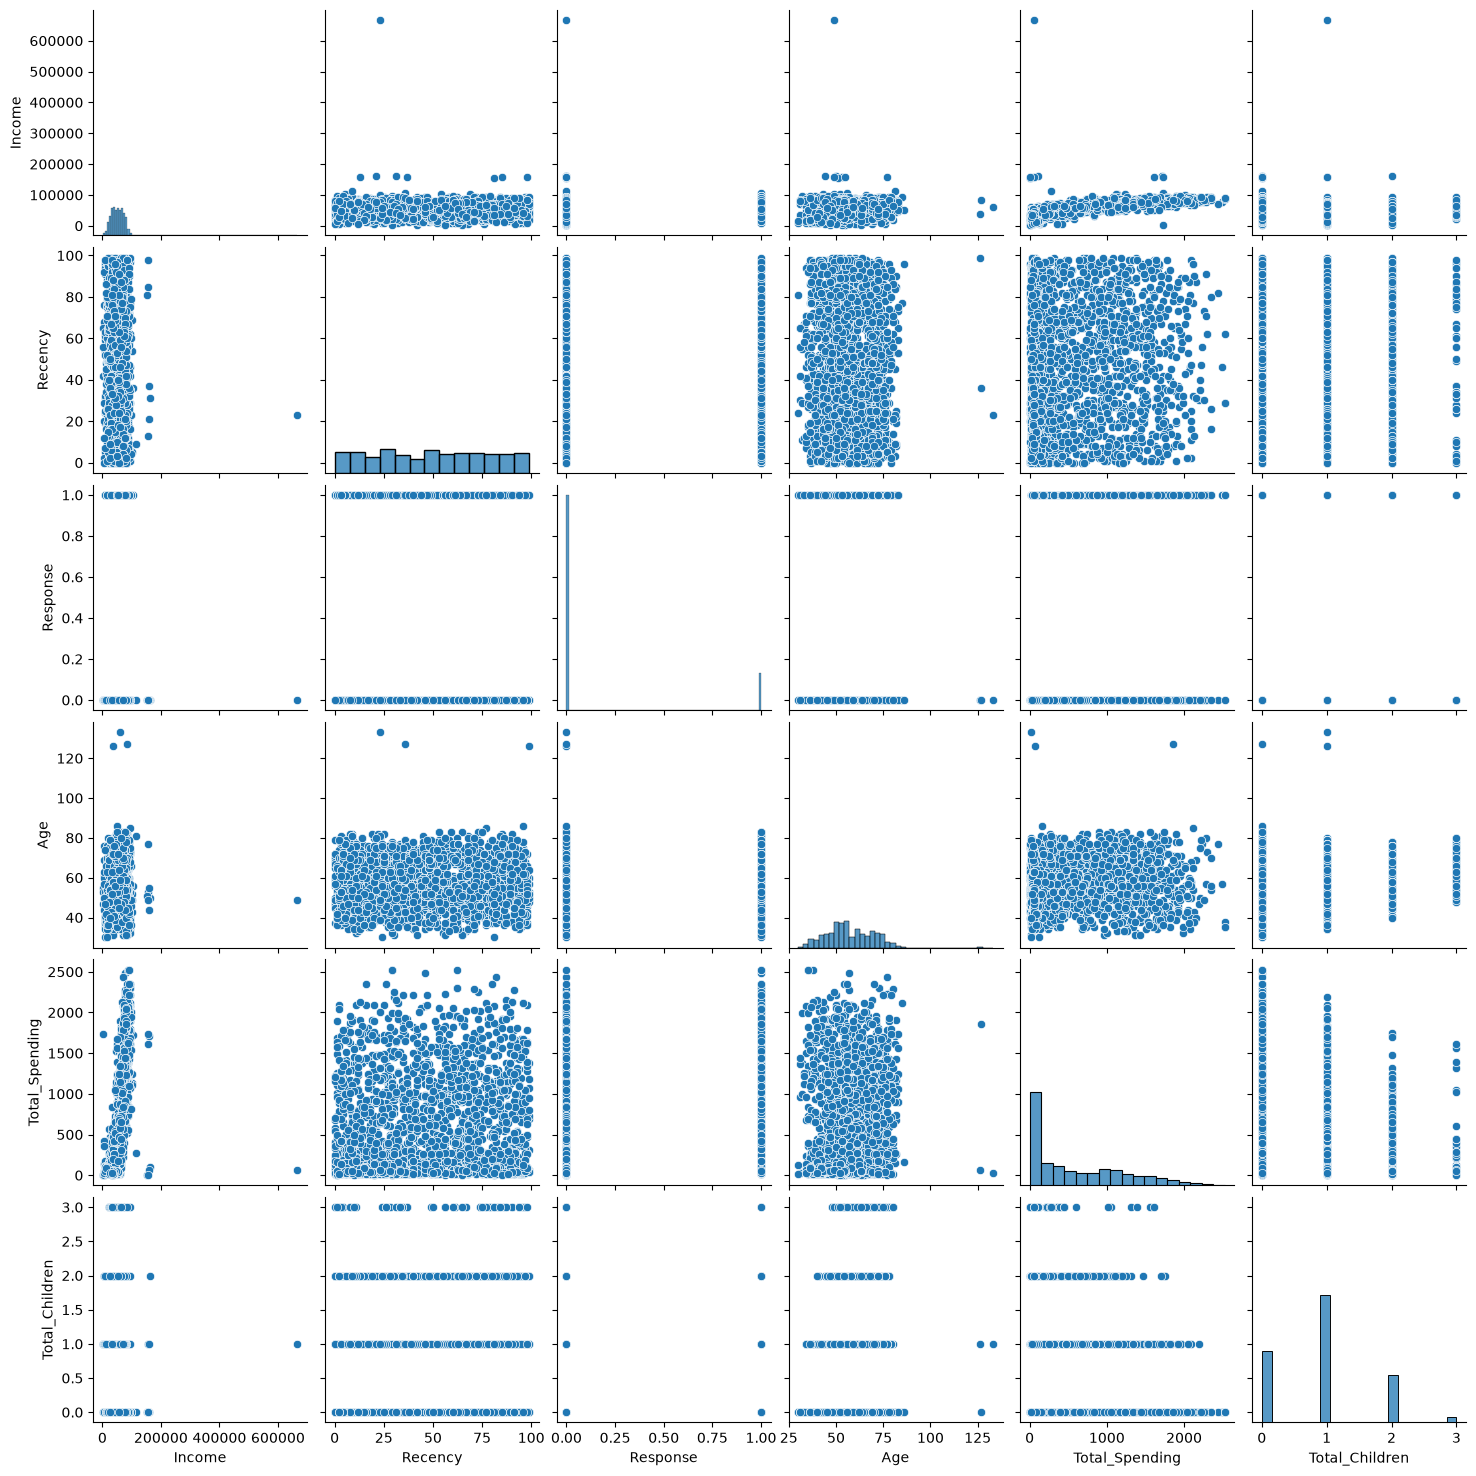

In [22]:
#Detecting and removing Outlier which can lead to inaccuracy

cols=["Income", "Recency", "Response", "Age", "Total_Spending", "Total_Children"]

#relative plots of some features - pair plots

sns.pairplot(df_cleaned[cols]) 


In [23]:
# Removing the Outliers

print("Data size with outliers: ", len(df_cleaned))

Data size with outliers:  2240


In [24]:
df_cleaned=df_cleaned[(df_cleaned["Age"]<90)]
df_cleaned=df_cleaned[(df_cleaned["Income"]<600_000)]

In [25]:
print("Data size without outliers: ", len(df_cleaned))

Data size without outliers:  2236


## Plotting heatmaps to check the correlation

In [26]:
corr=df_cleaned.corr(numeric_only=True)

<Axes: >

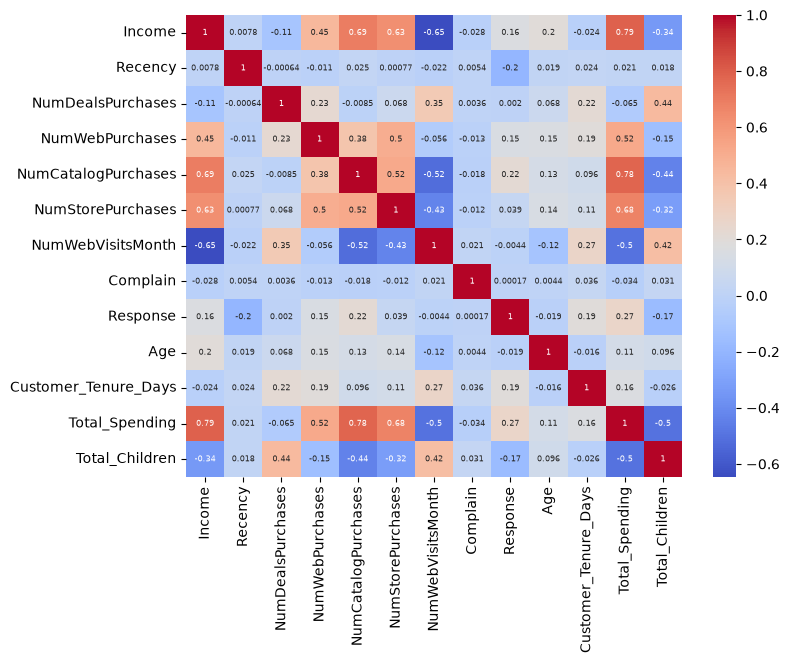

In [27]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size":6},
    cmap="coolwarm"
)

In [28]:
df_cleaned.shape

(2236, 15)

In [29]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


## Feature Encoding

In [30]:
from sklearn.preprocessing import OneHotEncoder

In [31]:
ohe=OneHotEncoder() #no need to do drop first=true to reduce collinearity because its not applicable for clustering

cat_cols=["Education","Living_With"]

enc_cols=ohe.fit_transform(df_cleaned[cat_cols])

In [32]:
enc_df=pd.DataFrame(enc_cols.toarray(), columns=ohe.get_feature_names_out(cat_cols), index=df_cleaned.index)

In [33]:
enc_df.head()

,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,1.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,1.0


In [34]:
df_encoded=pd.concat([df_cleaned.drop(columns=cat_cols),enc_df], axis=1)

In [35]:
df_encoded.shape

(2236, 18)

In [36]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0


## Scaling / Standardising

In [37]:
from sklearn.preprocessing import StandardScaler

In [38]:
X=df_encoded

In [39]:
scaler=StandardScaler()

X_scaled=scaler.fit_transform(X)

In [40]:
X_scaled=pd.DataFrame(X_scaled,columns=X.columns,index=X.index)

In [41]:
X_scaled.shape

(2236, 18)

In [42]:
X_scaled.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,0.288947,0.306856,0.348738,1.407639,2.509801,-0.552429,0.692865,-0.095001,2.386338,1.016868,1.529793,1.680176,-1.264308,0.992870,-0.786840,-0.35878,1.347635,-1.347635
1,-0.262003,-0.383971,-0.168700,-1.110921,-0.568970,-1.167738,-0.131421,-0.095001,-0.419052,1.273264,-1.191143,-0.962202,1.395139,0.992870,-0.786840,-0.35878,1.347635,-1.347635
2,0.918423,-0.798467,-0.686137,1.407639,-0.226884,1.293496,-0.543564,-0.095001,-0.419052,0.333146,-0.206659,0.282541,-1.264308,0.992870,-0.786840,-0.35878,-0.742041,0.742041
3,-1.182183,-0.798467,-0.168700,-0.751127,-0.911056,-0.552429,0.280722,-0.095001,-0.419052,-1.290693,-1.062517,-0.918994,0.065416,0.992870,-0.786840,-0.35878,-0.742041,0.742041
4,0.296187,1.550344,1.383614,0.328256,0.115201,0.062879,-0.131421,-0.095001,-0.419052,-1.034298,-0.953679,-0.305762,0.065416,-1.007181,1.270907,-0.35878,-0.742041,0.742041


## Visualize

In [43]:
#Reducing dimensions using PCA
from sklearn.decomposition import PCA

In [44]:
pca=PCA(n_components=3)

X_pca=pca.fit_transform(X_scaled)

In [45]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

Text(0.5, 0.92, '3d Projection')

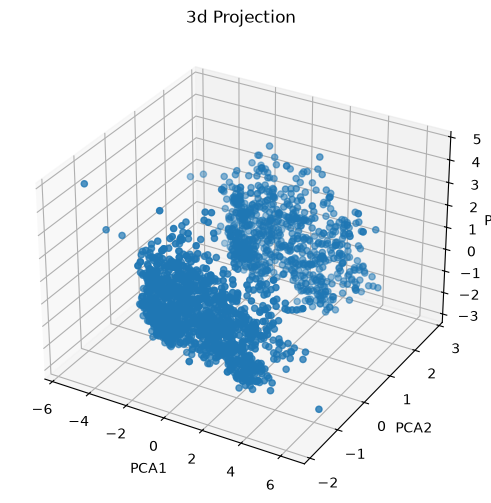

In [46]:
#Plot

fig=plt.figure(figsize=(8,6))

ax=fig.add_subplot(111, projection="3d")

ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2])

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3d Projection")

## Analyzing the K Value to find the clusters
### 1. Elbow Method

In [47]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss=[]

for K in range(1,11):
    kmeans=KMeans(n_clusters=K, random_state=42)
    labels=kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

In [48]:
wcss

[18093.257793324534,
 10760.843401758222,
 8830.288717243038,
 6650.969417658869,
 5006.161168001194,
 4396.308699108109,
 3857.633064427573,
 3207.057624221663,
 3025.2232554325856,
 2651.442989106149]

In [49]:
#Finding the elbow value using the kneed's KneeLocater

knee=KneeLocator(range(1,11), wcss , curve="convex", direction="decreasing")
optimal_k=knee.elbow

In [50]:
print("Best K:",optimal_k)  

Best K: 4


Text(0.5, 1.0, 'K vs WCSS')

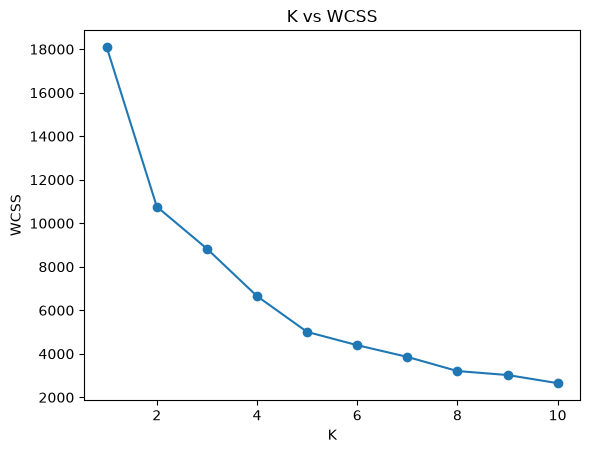

In [51]:
#Plotting the elbow value found using the kneed's KneeLocater

plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("K")
plt.ylabel("WCSS")
plt.title("K vs WCSS")

### 2. Silhouette Score

In [52]:
from sklearn.metrics import silhouette_score

scores=[]

for K in range(2,11):
    kmeans=KMeans(n_clusters=K, random_state=42)
    labels=kmeans.fit_predict(X_pca)
    score=silhouette_score(X_pca, labels)
    scores.append(score)

In [53]:
scores

[0.3715793907976336,
 0.307688192747433,
 0.3580996159596429,
 0.4000152147661341,
 0.39929183898567977,
 0.40262087405588853,
 0.4050858828690929,
 0.40118897046529645,
 0.40291173364821137]

Text(0.5, 1.0, 'K vs Silhouette Score')

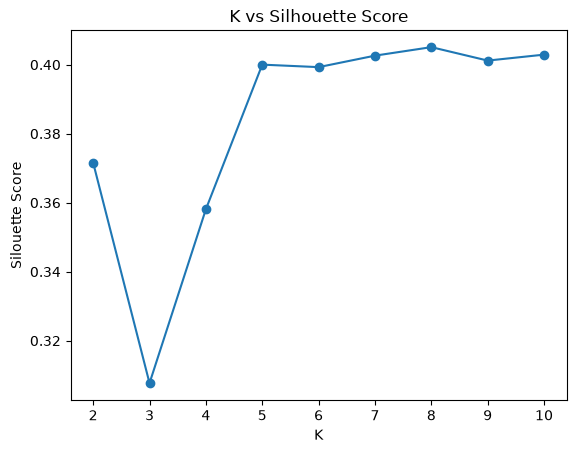

In [54]:
# Plotting K vs Silhouette Score

plt.plot(range(2,11), scores, marker='o')
plt.xlabel("K")
plt.ylabel("Silouette Score")
plt.title("K vs Silhouette Score")

Text(0, 0.5, 'Silhouette Score')

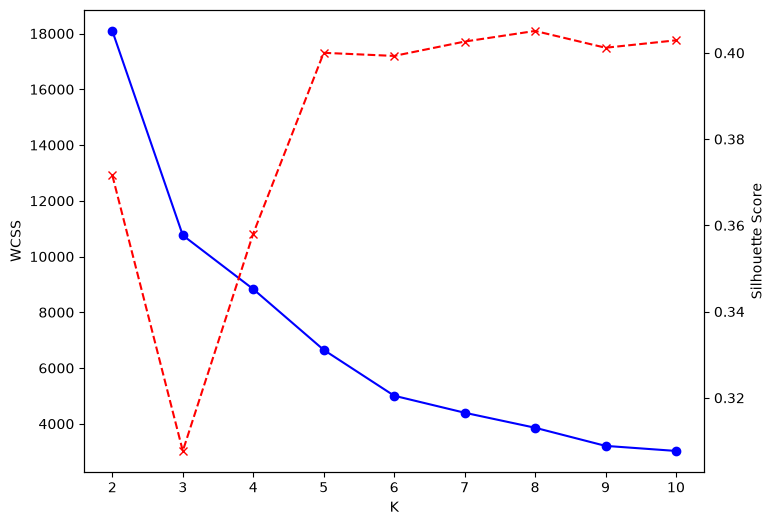

In [55]:
# Combined Plot

k_range=range(2,11)


fig , ax1=plt.subplots(figsize=(8,6))

ax1.plot(k_range, wcss[: len(k_range)], marker='o', color='blue')
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")

ax2=ax1.twinx()

ax2.plot(k_range, scores[: len(k_range)], marker='x', color='red', linestyle='--')
ax2.set_ylabel("Silhouette Score")

## Clustering

In [56]:
#K_means

kmeans=KMeans(n_clusters=4, random_state=42)

labels_kmeans=kmeans.fit_predict(X_pca)

Text(0.5, 0.92, '3d Projection')

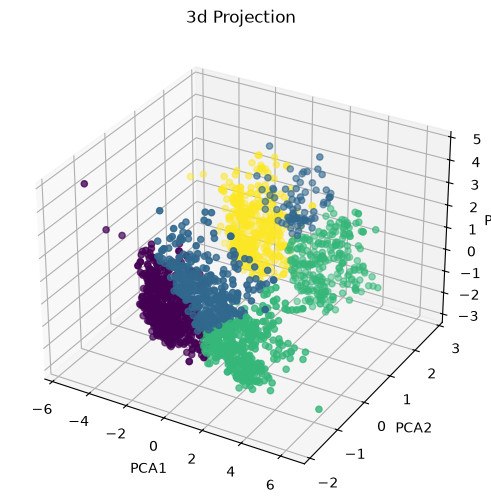

In [57]:
#Revisualize

fig=plt.figure(figsize=(8,6))

ax=fig.add_subplot(111, projection="3d")

ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=labels_kmeans)

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3d Projection")

In [58]:
#Heirarchial Agglomerative Clustering

from sklearn.cluster import AgglomerativeClustering

In [62]:
agg_clf=AgglomerativeClustering(n_clusters=4, linkage="ward")
labels_agg=agg_clf.fit_predict(X_pca)

Text(0.5, 0.92, '3d Projection')

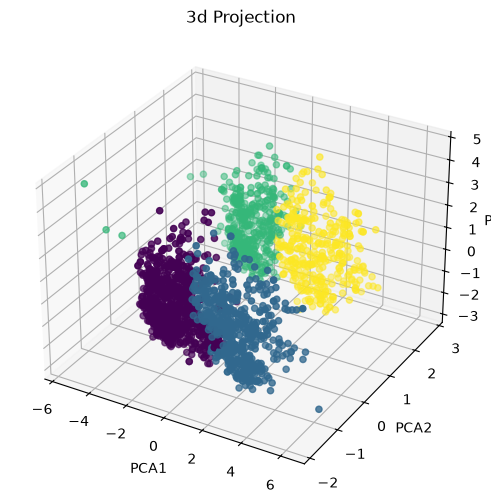

In [63]:
#Revisualize

fig=plt.figure(figsize=(8,6))

ax=fig.add_subplot(111, projection="3d")

ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=labels_agg)

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3d Projection")

## Characterization Of Clusters

In [87]:
X["cluster"]=labels_agg

In [88]:
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner,cluster
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0


<Axes: xlabel='cluster', ylabel='count'>

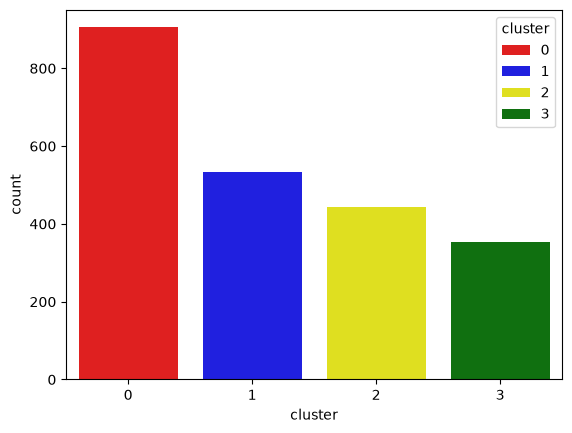

In [89]:
pal=["red","blue","yellow","green"]

sns.countplot(x=X["cluster"],palette=pal, hue=X["cluster"])

<Axes: xlabel='Total_Spending', ylabel='Income'>

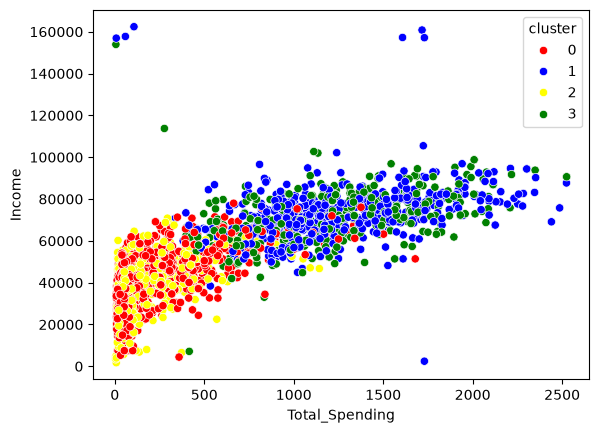

In [90]:
# Income and Spending Pattern

sns.scatterplot(x=X["Total_Spending"],y=X["Income"], hue=X["cluster"], palette=pal)  #Performing Better

# Cluster Summary

In [93]:
cluster_summary=X.groupby("cluster").mean()
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        39680.580110  48.914917           2.594475         3.153591   
1        72808.445693  49.202247           1.958801         5.687266   
2        36960.143018  48.319820           2.594595         2.713964   
3        70722.681303  50.504249           1.855524         5.790368   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   0.969061           4.143646           6.307182  0.011050   
1                   5.498127           8.659176           3.580524  0.005618   
2                   0.837838           3.623874           6.659910  0.011261   
3                   5.014164           8.430595           3.728045  0.005666   

         Response        Age  Customer_Tenure_Days  Total_Spending  \
cluster         